# Análise de Biomassa por Região

Baseado no `summary.csv` gerado por `src/calculate_biomass.py` (Longo et al. 2016).

**Três modelos:**
- **M1** — Chave 2014, todas as árvores, ρ médio (0.6 g/cm³)
- **M2** — equações separadas: vivas / mortas / palmeiras; ρ médio
- **M3** — igual M2 com ρ específico por espécie (GWDD Zanne/Chave 2009)

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

ROOT    = Path("..")
SUMMARY = ROOT / "data/processed/05_biomass/summary.csv"

plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False

C_M1, C_M2, C_M3 = "#4a90d9", "#f5a623", "#e84545"

s = pd.read_csv(SUMMARY)
s["site_short"] = s["site"].str.replace(r"_inventory_plots|_inventory", "", regex=True)
print(f"Plots: {len(s)} · Sites: {s.site.nunique()} · Com área: {s.area_ha.notna().sum()}")

Plots: 150 · Sites: 21 · Com área: 146


---
## 1. Distribuição de árvores por região

In [2]:
# Agrega por site
by_site = (
    s.groupby("site_short").agg(
        n_plots    =("plot_id",      "count"),
        area_ha    =("area_ha",      "sum"),
        n_arvores  =("n_arvores",    "sum"),
        n_vivas    =("n_arvores_vivas", "sum"),
        n_mortas   =("n_mortas",     "sum"),
        n_palmeiras=("n_palmeiras",  "sum"),
        agb_m1     =("agb_m1_Mg_ha", "mean"),
        agb_m2     =("agb_m2_Mg_ha", "mean"),
        agb_m3     =("agb_m3_Mg_ha", "mean"),
        agc_m1     =("agc_m1_MgC_ha","mean"),
        agc_m2     =("agc_m2_MgC_ha","mean"),
        agc_m3     =("agc_m3_MgC_ha","mean"),
    ).reset_index()
)
by_site["arvores_ha"] = (by_site["n_arvores"] / by_site["area_ha"]).round(1)
by_site = by_site.sort_values("n_arvores", ascending=True)

print(f"Total geral: {by_site.n_arvores.sum():,} árvores · {by_site.area_ha.sum():.1f} ha · {by_site.n_plots.sum()} plots")
print(by_site[["site_short","n_plots","area_ha","n_arvores","n_vivas","n_mortas","n_palmeiras","arvores_ha"]].to_string(index=False))

Total geral: 20,597 árvores · 71.7 ha · 150 plots
        site_short  n_plots  area_ha  n_arvores  n_vivas  n_mortas  n_palmeiras  arvores_ha
      JAM_A03_2013        1   0.9719         93        5        85            3        95.7
      TAN_A01_2012        1   0.9719         99       14        85            0       101.9
 SAN_A01_2014_2016        5   1.2591        102       93         9            0        81.0
      JAM_A02_2011        1   1.0130        108        1       103            4       106.6
      SAN_A02_2014        6   1.4612        154       74        10           70       105.4
      HUM_A01_2014       10   2.4946        251      228        13           10       100.6
SAN_A01b_2016_2018        6   1.4671        373      325        22           13       254.2
      JAM_A02_2013        1   6.0429        481       29       436           14        79.6
 PAR_A01_2013_2018        7   6.9076        491      431        58            1        71.1
      FST_A01_2013        4   

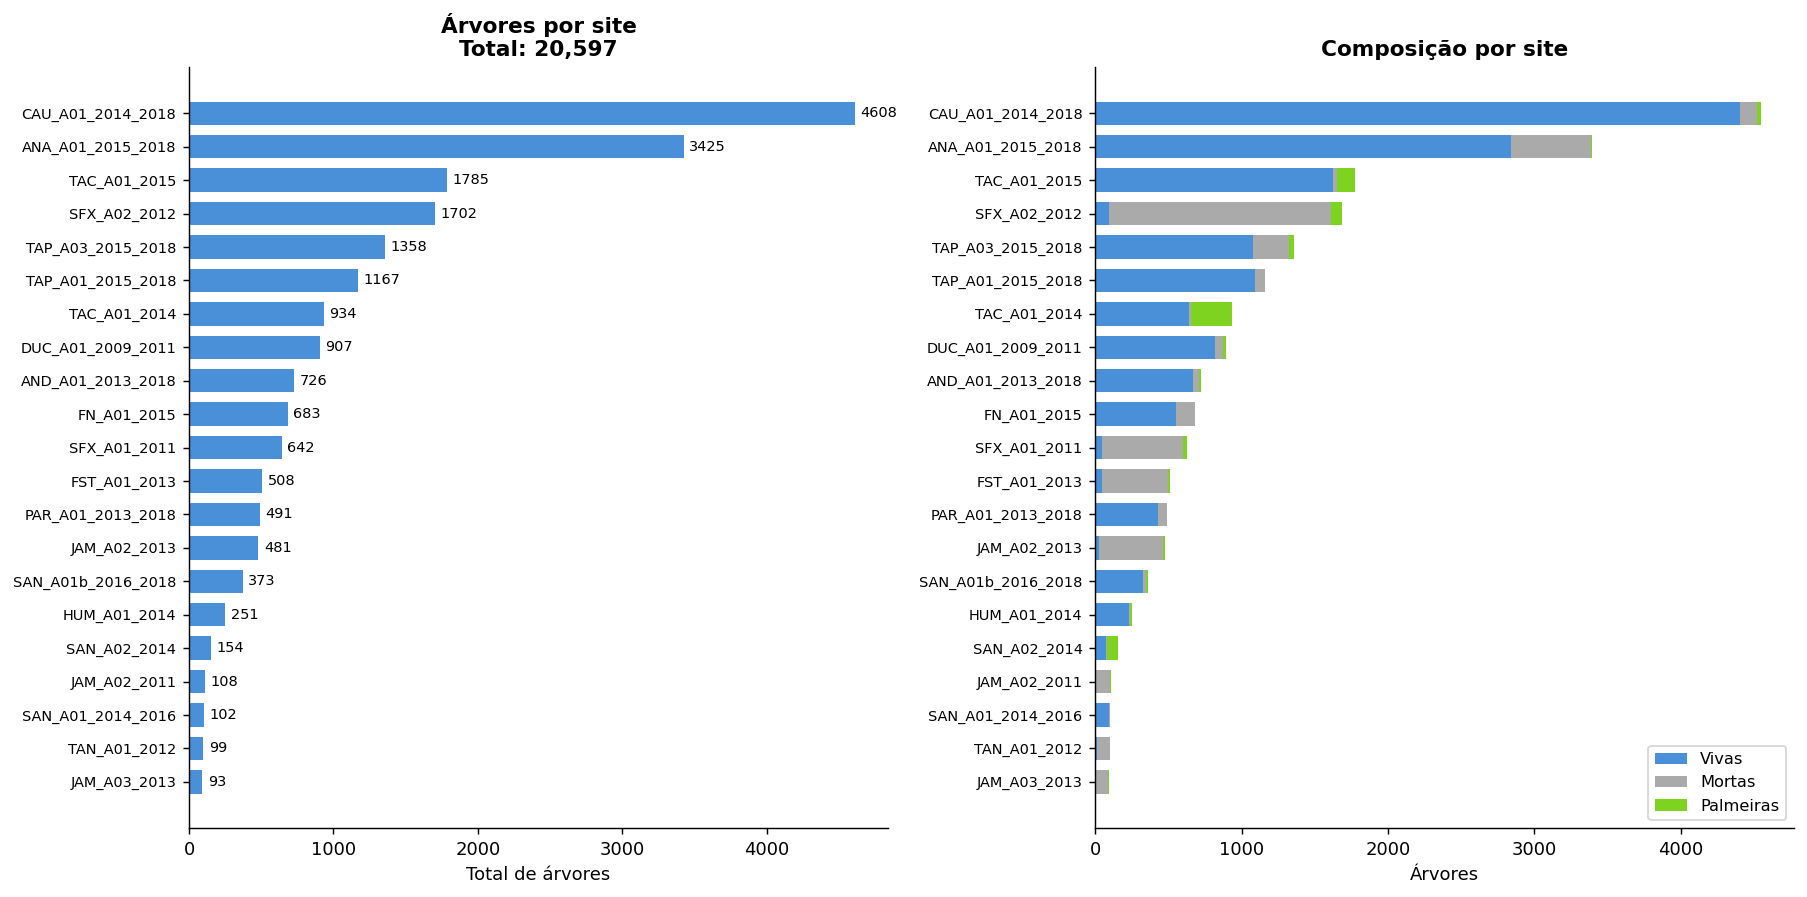

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# -- Total de árvores por site --
ax = axes[0]
bars = ax.barh(by_site["site_short"], by_site["n_arvores"], color="#4a90d9", height=0.7)
ax.bar_label(bars, padding=3, fontsize=8)
ax.set_xlabel("Total de árvores")
ax.set_title(f"Árvores por site\nTotal: {by_site.n_arvores.sum():,}", fontweight="bold")
ax.tick_params(axis="y", labelsize=8)

# -- Stacked: vivas / mortas / palmeiras --
ax = axes[1]
y = range(len(by_site))
ax.barh(y, by_site["n_vivas"],     color="#4a90d9", height=0.7, label="Vivas")
ax.barh(y, by_site["n_mortas"],    color="#aaaaaa", height=0.7,
        left=by_site["n_vivas"], label="Mortas")
ax.barh(y, by_site["n_palmeiras"], color="#7ed321", height=0.7,
        left=by_site["n_vivas"] + by_site["n_mortas"], label="Palmeiras")
ax.set_yticks(y)
ax.set_yticklabels(by_site["site_short"], fontsize=8)
ax.set_xlabel("Árvores")
ax.set_title("Composição por site", fontweight="bold")
ax.legend(fontsize=9, loc="lower right")

plt.tight_layout()
plt.show()

/tmp/ipykernel_145249/1102467573.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, vert=False, patch_artist=True, labels=order,


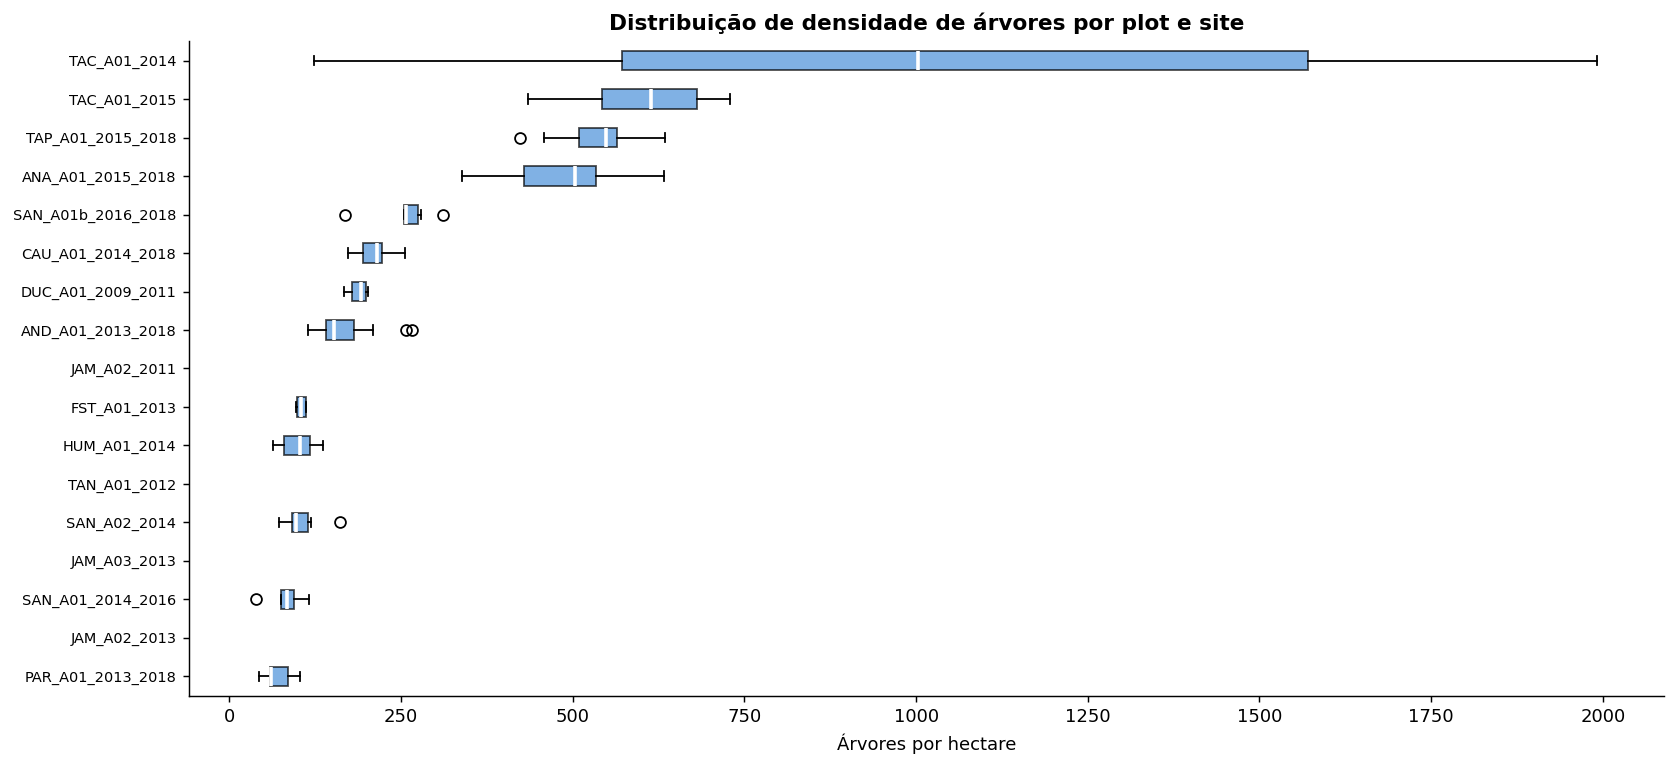

In [4]:
# Distribuição de árvores/ha por plot (boxplot por site)
s_valid = s[s["area_ha"].notna() & (s["area_ha"] > 0)].copy()
s_valid["arvores_ha"] = s_valid["n_arvores"] / s_valid["area_ha"]

order = s_valid.groupby("site_short")["arvores_ha"].median().sort_values().index
data  = [s_valid[s_valid["site_short"] == site]["arvores_ha"].values for site in order]

fig, ax = plt.subplots(figsize=(13, 6))
bp = ax.boxplot(data, vert=False, patch_artist=True, labels=order,
                medianprops=dict(color="white", linewidth=2))
for patch in bp["boxes"]:
    patch.set_facecolor("#4a90d9")
    patch.set_alpha(0.7)
ax.set_xlabel("Árvores por hectare")
ax.set_title("Distribuição de densidade de árvores por plot e site", fontweight="bold")
ax.tick_params(axis="y", labelsize=8)
plt.tight_layout()
plt.show()

---
## 2. Distribuição de biomassa por região

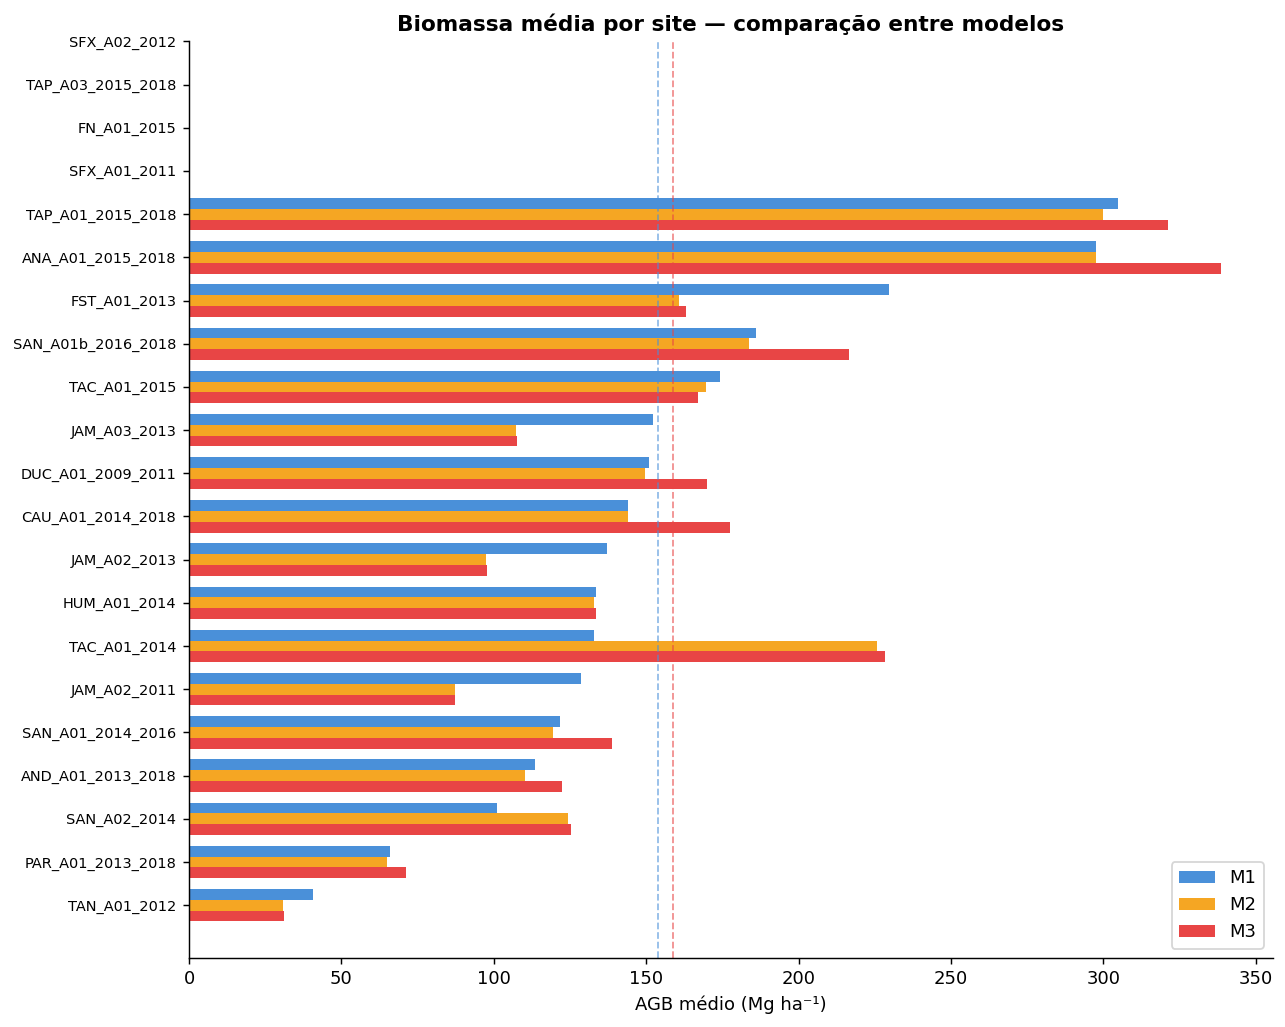

AGB médio global: M1=153.8 · M2=147.4 · M3=158.7 Mg/ha


In [5]:
# Biomassa média por site (AGB Mg/ha) para cada modelo
by_site_m = by_site.sort_values("agb_m1", ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
y = np.arange(len(by_site_m))
h = 0.25

ax.barh(y + h,   by_site_m["agb_m1"], height=h, color=C_M1, label="M1")
ax.barh(y,       by_site_m["agb_m2"], height=h, color=C_M2, label="M2")
ax.barh(y - h,   by_site_m["agb_m3"], height=h, color=C_M3, label="M3")

ax.set_yticks(y)
ax.set_yticklabels(by_site_m["site_short"], fontsize=8)
ax.set_xlabel("AGB médio (Mg ha⁻¹)")
ax.set_title("Biomassa média por site — comparação entre modelos", fontweight="bold")
ax.legend(fontsize=10)
ax.axvline(by_site_m["agb_m1"].mean(), color=C_M1, linestyle="--", linewidth=1, alpha=0.6)
ax.axvline(by_site_m["agb_m3"].mean(), color=C_M3, linestyle="--", linewidth=1, alpha=0.6)
plt.tight_layout()
plt.show()

print(f"AGB médio global: M1={by_site_m.agb_m1.mean():.1f} · M2={by_site_m.agb_m2.mean():.1f} · M3={by_site_m.agb_m3.mean():.1f} Mg/ha")

/tmp/ipykernel_145249/2864614229.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, vert=False, patch_artist=True, labels=order2,
/tmp/ipykernel_145249/2864614229.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, vert=False, patch_artist=True, labels=order2,


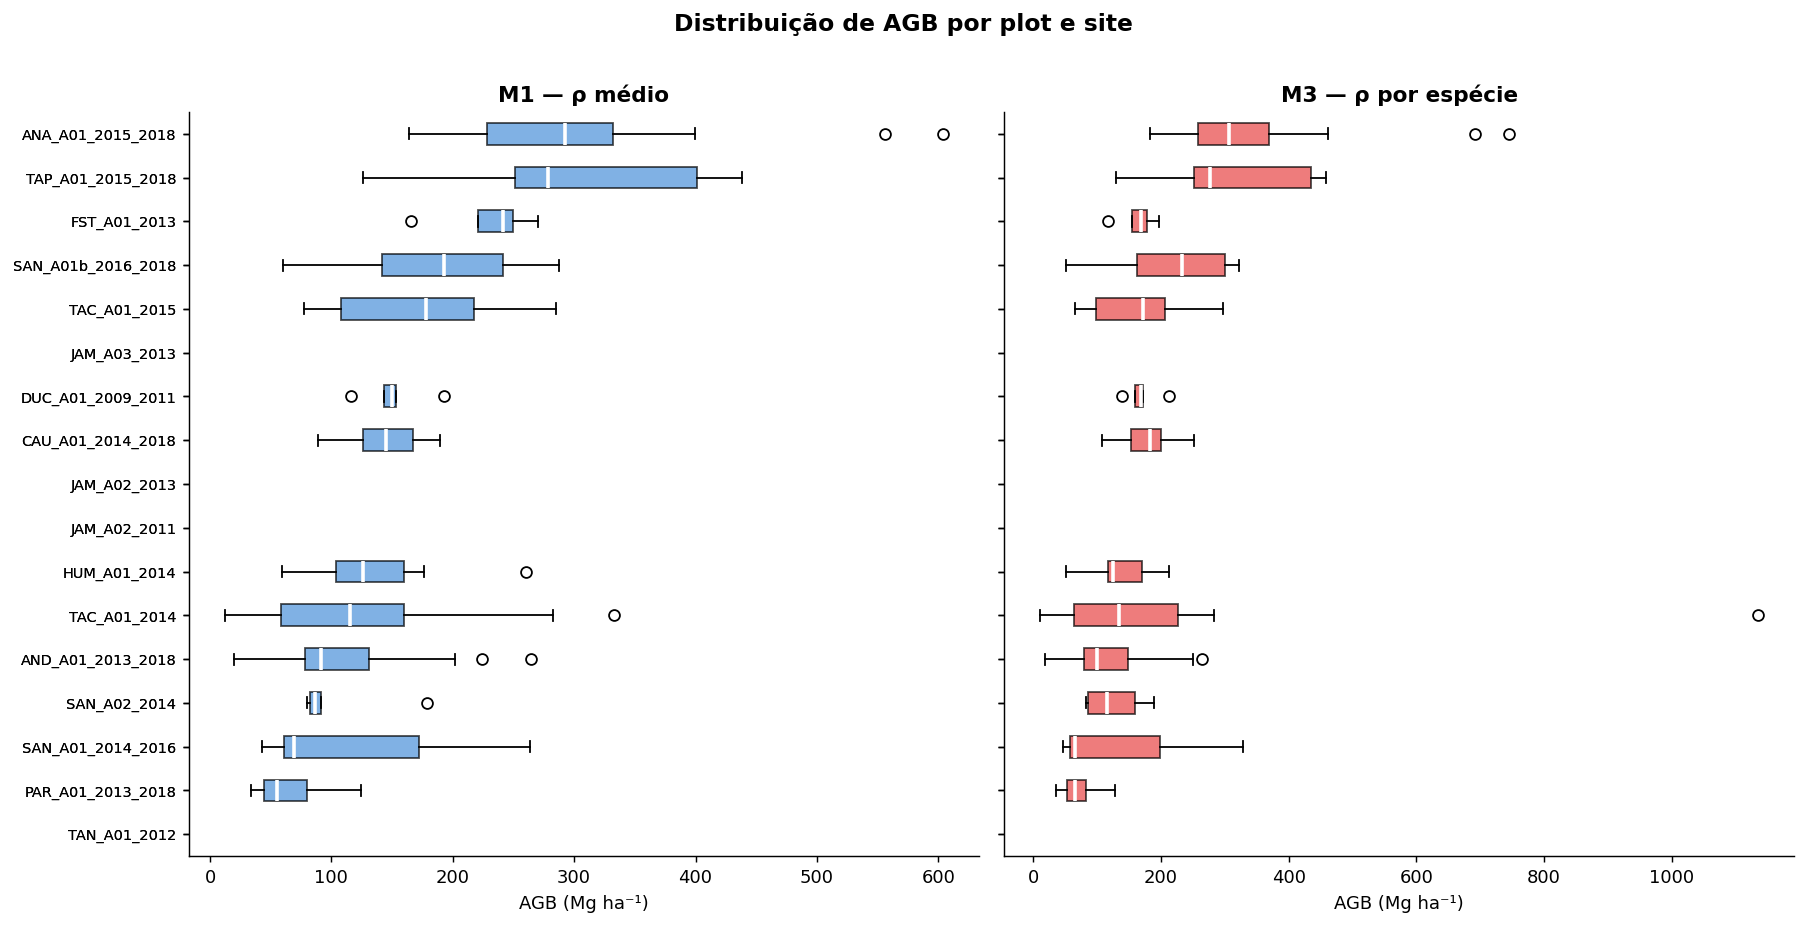

In [6]:
# Distribuição de AGB/ha por plot (boxplot) — M1 vs M3
order2 = s_valid.groupby("site_short")["agb_m1_Mg_ha"].median().sort_values().index
data_m1 = [s_valid[s_valid["site_short"] == site]["agb_m1_Mg_ha"].dropna().values for site in order2]
data_m3 = [s_valid[s_valid["site_short"] == site]["agb_m3_Mg_ha"].dropna().values for site in order2]

fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharey=True)
for ax, data, color, title in [
    (axes[0], data_m1, C_M1, "M1 — ρ médio"),
    (axes[1], data_m3, C_M3, "M3 — ρ por espécie"),
]:
    bp = ax.boxplot(data, vert=False, patch_artist=True, labels=order2,
                    medianprops=dict(color="white", linewidth=2))
    for patch in bp["boxes"]:
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_xlabel("AGB (Mg ha⁻¹)")
    ax.set_title(title, fontweight="bold")
    ax.tick_params(axis="y", labelsize=8)

plt.suptitle("Distribuição de AGB por plot e site", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

---
## 3. Árvores/ha e Biomassa/ha por modelo

In [7]:
# Tabela consolidada por site
tbl = by_site[["site_short","n_plots","area_ha","n_arvores","arvores_ha",
               "agb_m1","agb_m2","agb_m3","agc_m1","agc_m2","agc_m3"]].copy()
tbl.columns = ["site","plots","area_ha","n_arvores","arv_ha",
               "agb_M1","agb_M2","agb_M3","agc_M1","agc_M2","agc_M3"]
tbl = tbl.sort_values("agb_M3", ascending=False).reset_index(drop=True)

print("Tabela consolidada por site (biomassa média por plot em Mg/ha e MgC/ha):")
print(tbl.round(1).to_string(index=False))

Tabela consolidada por site (biomassa média por plot em Mg/ha e MgC/ha):
              site  plots  area_ha  n_arvores  arv_ha  agb_M1  agb_M2  agb_M3  agc_M1  agc_M2  agc_M3
 ANA_A01_2015_2018     28      7.1       3425   484.4   297.6   297.5   338.7   148.8   148.8   169.3
 TAP_A01_2015_2018      9      2.2       1167   532.3   304.9   299.9   321.2   152.5   149.9   160.6
      TAC_A01_2014     10      0.9        934  1044.6   133.0   225.6   228.4    66.5   112.8   114.2
SAN_A01b_2016_2018      6      1.5        373   254.2   185.9   183.8   216.6    93.0    91.9   108.3
 CAU_A01_2014_2018     22     22.0       4608   209.7   143.9   143.9   177.6    72.0    71.9    88.8
 DUC_A01_2009_2011      5      4.8        907   188.0   151.0   149.7   170.0    75.5    74.8    85.0
      TAC_A01_2015     12      3.0       1785   598.3   174.1   169.8   166.9    87.0    84.9    83.5
      FST_A01_2013      4      4.8        508   105.1   229.6   160.7   162.9   114.8    80.4    81.5
 SAN_A01_

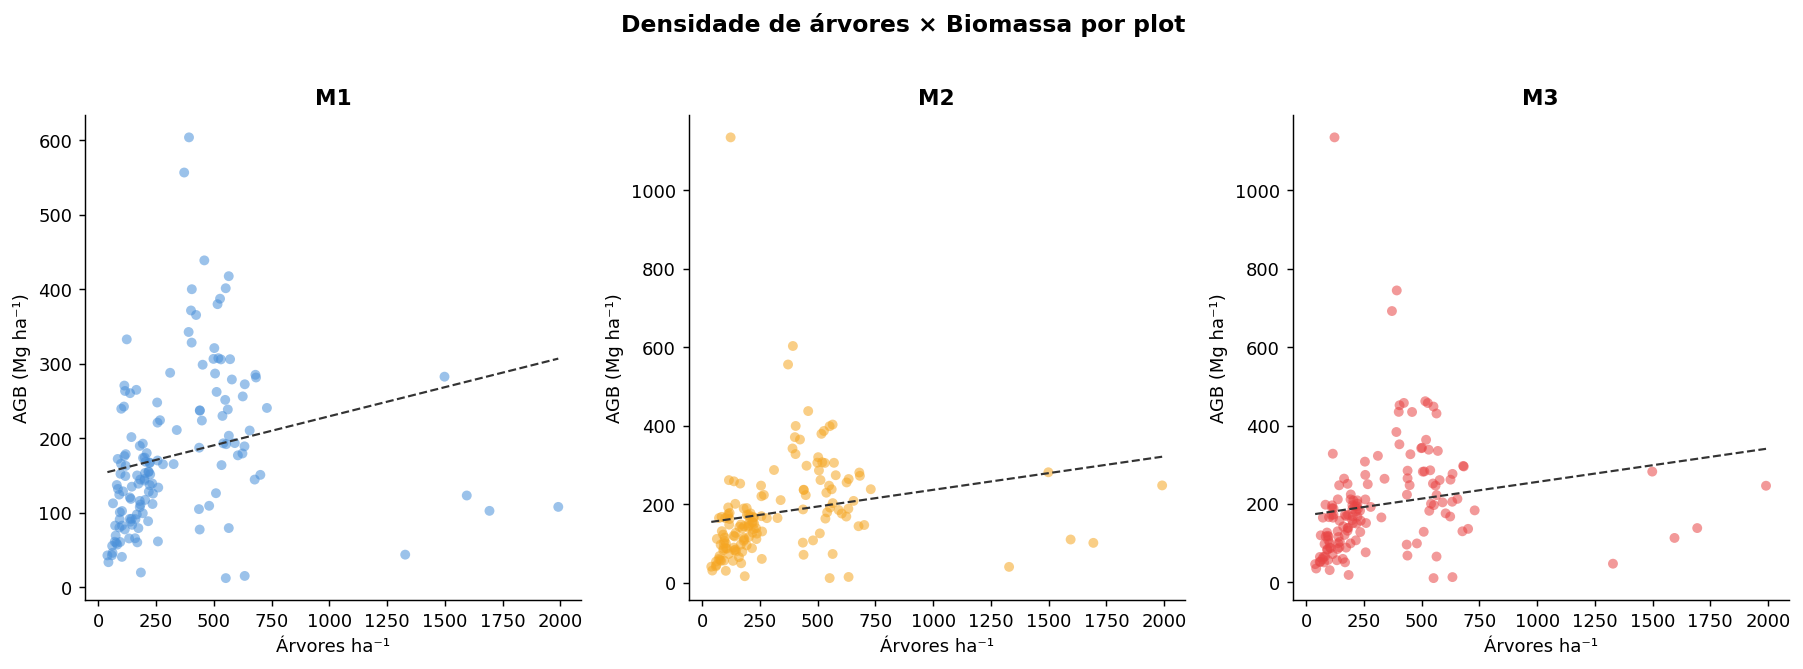

In [8]:
# Scatter: árvores/ha × AGB/ha (colorido por modelo)
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=False)

for ax, col, color, title in [
    (axes[0], "agb_m1_Mg_ha", C_M1, "M1"),
    (axes[1], "agb_m2_Mg_ha", C_M2, "M2"),
    (axes[2], "agb_m3_Mg_ha", C_M3, "M3"),
]:
    sv = s_valid.copy()
    sv["arv_ha"] = sv["n_arvores"] / sv["area_ha"]
    ax.scatter(sv["arv_ha"], sv[col], alpha=0.55, color=color, s=30, edgecolors="none")

    # Linha de tendência
    mask = sv[col].notna() & sv["arv_ha"].notna()
    if mask.sum() > 2:
        z = np.polyfit(sv.loc[mask, "arv_ha"], sv.loc[mask, col], 1)
        xr = np.linspace(sv["arv_ha"].min(), sv["arv_ha"].max(), 100)
        ax.plot(xr, np.polyval(z, xr), color="#333", linewidth=1.2, linestyle="--")

    ax.set_xlabel("Árvores ha⁻¹")
    ax.set_ylabel("AGB (Mg ha⁻¹)")
    ax.set_title(title, fontweight="bold")

plt.suptitle("Densidade de árvores × Biomassa por plot", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

/tmp/ipykernel_145249/127952453.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_d, vert=False, patch_artist=True, labels=order3,


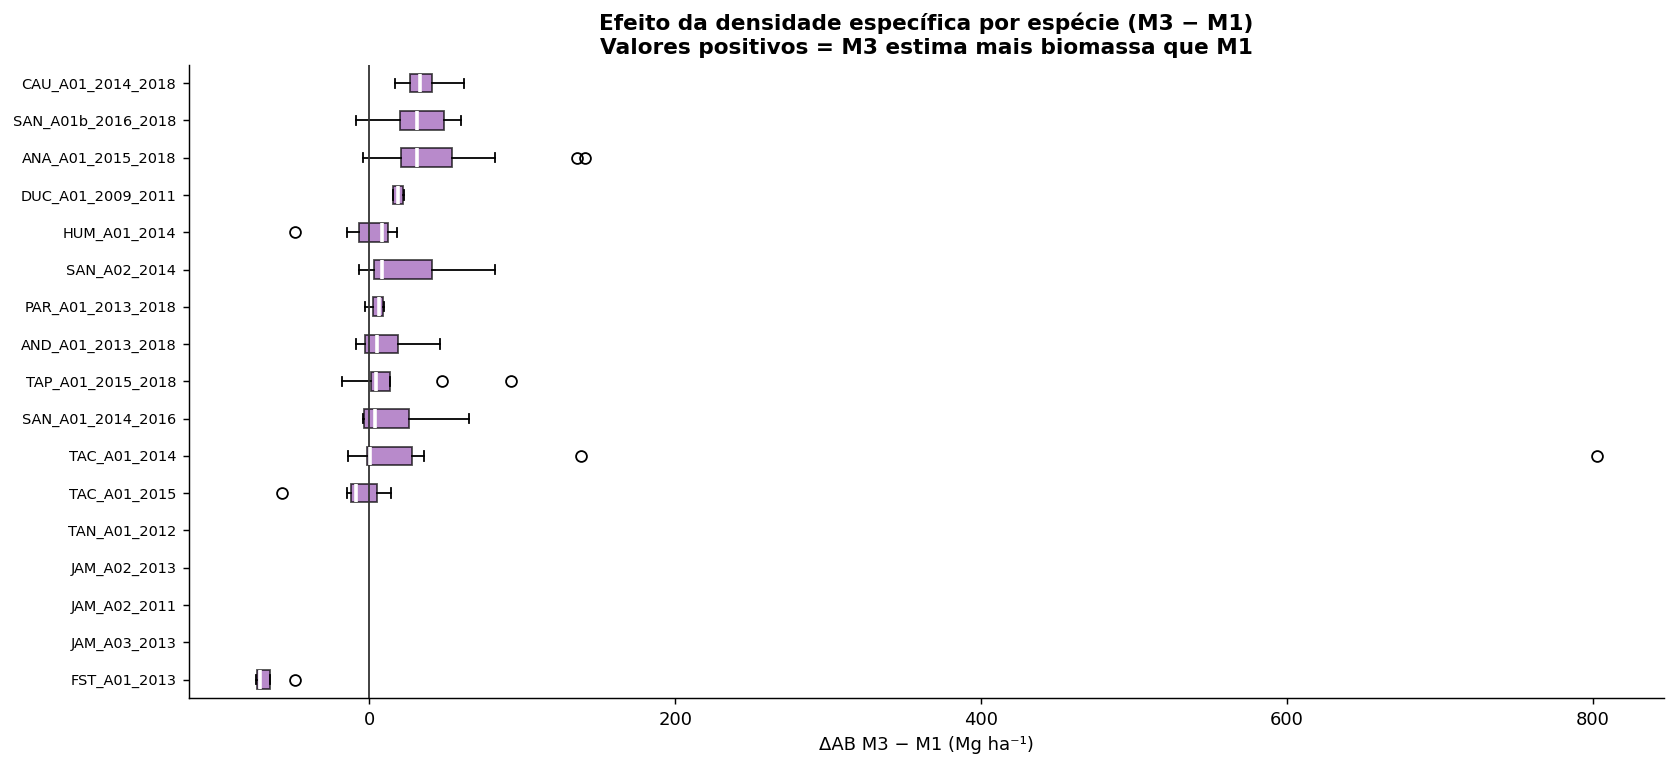

Diferença M3−M1 global:  mediana=14.6  média=22.0 Mg/ha
Sites onde M3 > M1:  11 de 17


In [9]:
# Diferença entre modelos: quanto o M3 difere do M1?
s_valid["delta_m3_m1"] = s_valid["agb_m3_Mg_ha"] - s_valid["agb_m1_Mg_ha"]
order3 = s_valid.groupby("site_short")["delta_m3_m1"].median().sort_values().index
data_d = [s_valid[s_valid["site_short"] == site]["delta_m3_m1"].dropna().values for site in order3]

fig, ax = plt.subplots(figsize=(13, 6))
bp = ax.boxplot(data_d, vert=False, patch_artist=True, labels=order3,
                medianprops=dict(color="white", linewidth=2))
for patch in bp["boxes"]:
    patch.set_facecolor("#9b59b6")
    patch.set_alpha(0.7)
ax.axvline(0, color="#333", linewidth=1, linestyle="-")
ax.set_xlabel("ΔAB M3 − M1 (Mg ha⁻¹)")
ax.set_title("Efeito da densidade específica por espécie (M3 − M1)\nValores positivos = M3 estima mais biomassa que M1",
             fontweight="bold")
ax.tick_params(axis="y", labelsize=8)
plt.tight_layout()
plt.show()

print(f"Diferença M3−M1 global:  mediana={s_valid.delta_m3_m1.median():.1f}  média={s_valid.delta_m3_m1.mean():.1f} Mg/ha")
print(f"Sites onde M3 > M1:  {(s_valid.groupby('site_short')['delta_m3_m1'].median() > 0).sum()} de {s_valid.site_short.nunique()}")

In [10]:
# Resumo estatístico global
print("=" * 60)
print("RESUMO GLOBAL")
print("=" * 60)
print(f"  Sites:    {s.site.nunique()}")
print(f"  Plots:    {len(s)} ({s.area_ha.notna().sum()} com área conhecida)")
print(f"  Árvores:  {s.n_arvores.sum():,}  (vivas: {s.n_arvores_vivas.sum():,}  "
      f"mortas: {s.n_mortas.sum():,}  palmeiras: {s.n_palmeiras.sum():,})")
print(f"  Área:     {s.area_ha.sum():.1f} ha")
print()
print(f"  {'Modelo':<10} {'AGB médio':>14} {'AGB mediana':>14} {'AGB min':>10} {'AGB max':>10}")
for m, col in [("M1","agb_m1_Mg_ha"),("M2","agb_m2_Mg_ha"),("M3","agb_m3_Mg_ha")]:
    v = s_valid[col].dropna()
    print(f"  {m:<10} {v.mean():>12.1f}  {v.median():>12.1f}  {v.min():>8.1f}  {v.max():>8.1f}  Mg/ha")
print()
print(f"  {'Modelo':<10} {'AGC médio':>14} {'AGC mediana':>14}")
for m, col in [("M1","agc_m1_MgC_ha"),("M2","agc_m2_MgC_ha"),("M3","agc_m3_MgC_ha")]:
    v = s_valid[col].dropna()
    print(f"  {m:<10} {v.mean():>12.1f}  {v.median():>12.1f}  MgC/ha")

RESUMO GLOBAL
  Sites:    21
  Plots:    150 (146 com área conhecida)
  Árvores:  20,597  (vivas: 15,102  mortas: 4,582  palmeiras: 737)
  Área:     71.7 ha

  Modelo          AGB médio    AGB mediana    AGB min    AGB max
  M1                177.8         154.9      12.3     603.7  Mg/ha
  M2                181.0         158.9      12.3    1135.2  Mg/ha
  M3                199.8         172.4      10.8    1135.2  Mg/ha

  Modelo          AGC médio    AGC mediana
  M1                 88.9          77.5  MgC/ha
  M2                 90.5          79.5  MgC/ha
  M3                 99.9          86.2  MgC/ha
